In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('marks.csv')
print(data.head())

# Features and target
hours = data[['Hours']]
scores = data['Scores']

# Train model
model = LinearRegression().fit(hours, scores)

# Predict user input
pred = float(input("Enter number of study hours: "))
predicted_score = model.predict([[pred]])
print(f"Predicted score for studying {pred} hours: {predicted_score[0]}")

# Predict scores for all data (for evaluation)
all_predictions = model.predict(hours)

# Model evaluation
mae = mean_absolute_error(scores, all_predictions)
mse = mean_squared_error(scores, all_predictions)
rmse = np.sqrt(mse)

# Print metrics
print(f"Mean Absolute Error: {round(mae)}")
print(f"Mean Squared Error: {round(mse)}")
print(f"Root Mean Squared Error: {round(rmse)}")

r2_score = model.score(hours, scores)
print(f"R^2 Score: {round(r2_score)}")

print(f"Model Coefficient: {round(model.coef_[0])}")
print(f"Model Intercept: {round(model.intercept_)}")


   Hours  Scores
0      1      40
1      2      50
2      3      65
3      4      80
4      5      95
Predicted score for studying 23.0 hours: 322.38095238095235
Mean Absolute Error: 2
Mean Squared Error: 7
Root Mean Squared Error: 3
R^2 Score: 1
Model Coefficient: 13
Model Intercept: 27


c:\Users\pc\Documents\AIML\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Scores Obtained')

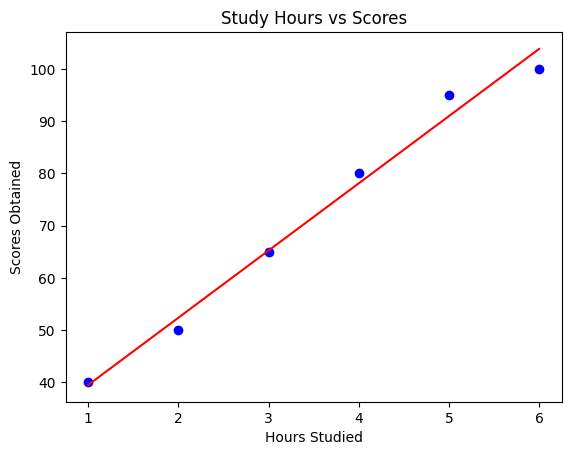

In [2]:
# Visualization
plt.scatter(hours, scores, color='blue', label='Actual Scores')
plt.plot(hours, all_predictions, color='red', label='Regression Line')
plt.title('Study Hours vs Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores Obtained')

c:\Users\pc\Documents\AIML\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


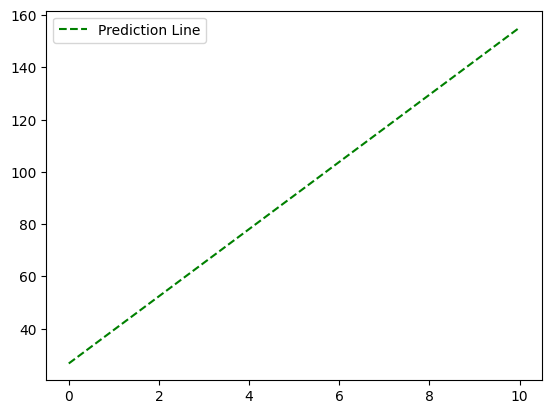

<Figure size 640x480 with 0 Axes>

In [3]:
predicted_line = model.predict(np.array([[0], [10]]))
plt.plot([0, 10], predicted_line, color='green', linestyle='--', label='Prediction Line')
plt.legend()
plt.show()
plt.savefig('regression_plot.png')

In [4]:
pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R^2 Score', 'Coefficient', 'Intercept'],
    'Value': [round(mae), round(mse), round(rmse), round(r2_score), round(model.coef_[0]), round(model.intercept_)]
}).to_csv('model_metrics.csv', index=False) 

In [ ]:
# Save predictions
data['Predicted_Scores'] = all_predictions
data.to_csv('predicted_scores.csv', index=False)